# Summarize Genomic GCM Results

This notebook provides compact summaries of the genomic GCM experiments.

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
RESULTS_PATH = "results/results.npz"


SAVE_FIGURES = False
FIGURE_DIR = "figures"          # only used when SAVE_FIGURES is True

SHOW_INDIVIDUAL = True          # overlay individual simulation results as open circles

In [2]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.constrained_layout.use": True,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

if SAVE_FIGURES:
    os.makedirs(FIGURE_DIR, exist_ok=True)

In [3]:
# ── Load & parse ─────────────────────────────────────────────────────────────
raw = dict(np.load(RESULTS_PATH, allow_pickle=True))

# Print saved args
args_keys = sorted(k for k in raw if k.startswith("args/"))
if args_keys:
    print("Experiment arguments:")
    for k in args_keys:
        print(f"  {k.split('/', 1)[1]:20s} = {raw[k]}")

ALL_MODELS = ["naive", "standard_rc", "standard_no_rc", "reparam_rc", "reparam_no_rc"]
MODEL_LABELS = {
    "naive": "Naive",
    "standard_rc": "Standard (RC)",
    "standard_no_rc": "Standard",
    "reparam_rc": "Reparam (RC)",
    "reparam_no_rc": "Reparam",
}

COND_RE = re.compile(
    r"repeat=(?P<repeat>\d+)_scenario=(?P<scenario>\d+)"
    r"_noise=(?P<noise>[\d.]+)_subset=(?P<subset>\d+)"
)

rows = []
loss_curves = {}  # (repeat, scenario, noise, subset, model) -> 1-D array

condition_keys = set()
for k in raw:
    m = COND_RE.match(k)
    if m:
        condition_keys.add(k[: m.end()])

for cond in sorted(condition_keys):
    m = COND_RE.match(cond)
    rep = int(m.group("repeat"))
    scen = int(m.group("scenario"))
    noise = float(m.group("noise"))
    subset = int(m.group("subset"))

    for model in ALL_MODELS:
        te_key = f"{cond}/{model}/te_mse"
        pred_key = f"{cond}/{model}/pred_mse"
        loss_key = f"{cond}/{model}/losses"
        if te_key not in raw:
            continue
        rows.append({
            "repeat": rep,
            "scenario": scen,
            "noise": noise,
            "subset": subset,
            "model": model,
            "te_mse": float(raw[te_key]),
            "pred_mse": float(raw[pred_key]),
        })
        if loss_key in raw:
            loss_curves[(rep, scen, noise, subset, model)] = np.array(raw[loss_key])

df = pd.DataFrame(rows)
models_present = [m for m in ALL_MODELS if m in df["model"].values]
print(f"\nLoaded {len(df)} rows  |  models: {models_present}")
print(f"scenarios: {sorted(df['scenario'].unique())}")
print(f"noise levels: {sorted(df['noise'].unique())}")
print(f"subsets: {sorted(df['subset'].unique())}")
print(f"repeats: {df['repeat'].nunique()}")

Experiment arguments:
  include_no_rc        = True
  noise                = [0.1 0.3]
  num_steps            = 150000
  repeats              = 10
  scenarios            = [0 1]
  seed                 = 45
  subsets              = [1000]

Loaded 200 rows  |  models: ['naive', 'standard_rc', 'standard_no_rc', 'reparam_rc', 'reparam_no_rc']
scenarios: [np.int64(0), np.int64(1)]
noise levels: [np.float64(0.1), np.float64(0.3)]
subsets: [np.int64(1000)]
repeats: 10


In [4]:
# ── Plotting helpers ─────────────────────────────────────────────────────────
MODEL_COLORS = {
    "naive": "#888888",
    "standard_rc": "#1b9e77",
    "standard_no_rc": "#7fc97f",
    "reparam_rc": "#d95f02",
    "reparam_no_rc": "#fdb863",
}


def _save(fig, name):
    if SAVE_FIGURES:
        fig.savefig(os.path.join(FIGURE_DIR, name), bbox_inches="tight")


def bar_plot(df_sub, metric, ylabel, title, ax, models=None, show_individual=True):
    """Grouped bar chart of *metric* across models with SE error bars."""
    if models is None:
        models = [m for m in ALL_MODELS if m in df_sub["model"].values]
    means, ses, xs, colors, labels = [], [], [], [], []
    for i, model in enumerate(models):
        vals = df_sub.loc[df_sub["model"] == model, metric].values
        if len(vals) == 0:
            continue
        means.append(vals.mean())
        ses.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
        xs.append(i)
        colors.append(MODEL_COLORS[model])
        labels.append(MODEL_LABELS[model])
        if show_individual and len(vals) > 1:
            jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(
                np.full_like(vals, i) + jitter, vals,
                facecolors="none", edgecolors=MODEL_COLORS[model],
                s=18, linewidths=0.7, zorder=3,
            )
    ax.bar(xs, means, yerr=ses, capsize=3, color=colors, edgecolor="white",
           linewidth=0.5, width=0.6, zorder=2, alpha=0.85)
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    #ax.set_ylim([0, 8])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.spines[["top", "right"]].set_visible(False)


def latex_table(df_in, metrics, group_col=None, group_label=None, caption=None):
    """Print a LaTeX table of mean (SE) with models as columns.

    Args:
        df_in: DataFrame with columns 'model' and the requested metrics.
        metrics: str or list of str – metric column name(s).
        group_col: optional column to break rows by (e.g. 'scenario').
        group_label: display name for the group column.
        caption: optional table caption.
    """
    if isinstance(metrics, str):
        metrics = [metrics]
    metric_labels = {"te_mse": "TE MSE", "pred_mse": "Pred MSE"}
    models = [m for m in ALL_MODELS if m in df_in["model"].values]
    col_heads = [MODEL_LABELS[m] for m in models]

    groups = sorted(df_in[group_col].unique()) if group_col else [None]
    multi_metric = len(metrics) > 1

    lines = []
    lines.append(r"\begin{tabular}{l " + " ".join(["c"] * len(models)) + "}")
    lines.append(r"\toprule")
    lines.append(" & ".join([""] + col_heads) + r" \\")
    lines.append(r"\midrule")

    for g in groups:
        for mi, metric in enumerate(metrics):
            if group_col is not None:
                sub = df_in[df_in[group_col] == g]
            else:
                sub = df_in

            cells = []
            for model in models:
                vals = sub.loc[sub["model"] == model, metric].values
                if len(vals) == 0:
                    cells.append("--")
                    continue
                mn = vals.mean()
                se = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
                cells.append(f"{mn:.3f} ({se:.3f})")

            row_label_parts = []
            if group_col is not None:
                row_label_parts.append(f"{group_label or group_col} {g}")
            if multi_metric:
                row_label_parts.append(metric_labels.get(metric, metric))
            row_label = ", ".join(row_label_parts) if row_label_parts else metric_labels.get(metric, metric)
            lines.append(" & ".join([row_label] + cells) + r" \\")

        if group_col is not None and g != groups[-1]:
            lines.append(r"\addlinespace")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    if caption:
        print(f"% {caption}")
    print("\n".join(lines))

## Treatment-effect MSE

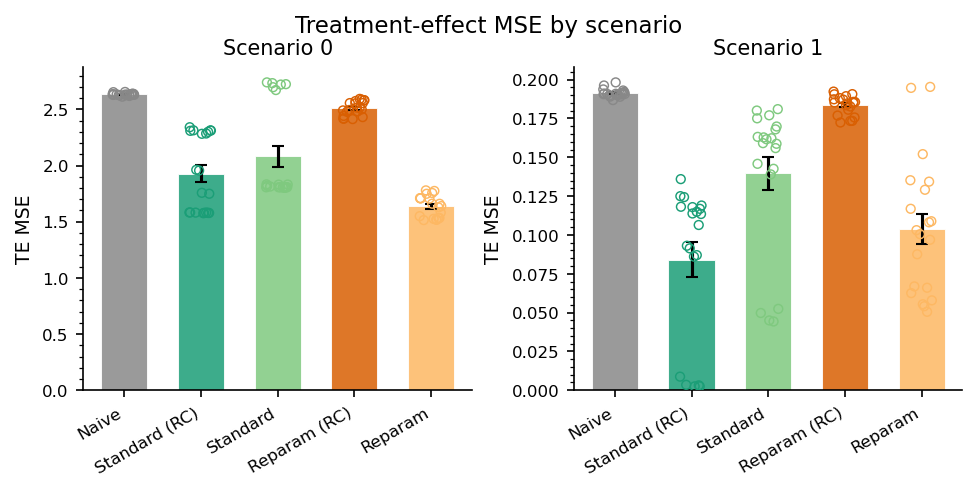

In [5]:
scenarios = sorted(df["scenario"].unique())
fig, axes = plt.subplots(1, len(scenarios), figsize=(3.2 * len(scenarios), 3))
if len(scenarios) == 1:
    axes = [axes]
for ax, scen in zip(axes, scenarios):
    bar_plot(
        df[df["scenario"] == scen], "te_mse", "TE MSE",
        f"Scenario {scen}", ax, show_individual=SHOW_INDIVIDUAL,
    )
    
fig.suptitle("Treatment-effect MSE by scenario", y=1.04, fontsize=11)
_save(fig, "te_mse_by_scenario.pdf")
plt.show()

In [6]:
latex_table(df, "te_mse", group_col="scenario", group_label="Scenario",
            caption="Treatment-effect MSE by scenario")

% Treatment-effect MSE by scenario
\begin{tabular}{l c c c c c}
\toprule
 & Naive & Standard (RC) & Standard & Reparam (RC) & Reparam \\
\midrule
Scenario 0 & 2.633 (0.002) & 1.926 (0.076) & 2.083 (0.095) & 2.509 (0.014) & 1.637 (0.021) \\
\addlinespace
Scenario 1 & 0.191 (0.001) & 0.084 (0.011) & 0.140 (0.011) & 0.184 (0.001) & 0.104 (0.010) \\
\bottomrule
\end{tabular}
